# Phase 1 — Modern UTXO Exploration (2017–2026)

This notebook analyzes Bitcoin’s UTXO system from the activation of SegWit (block 481,824, August 2017) up to the present (~945,000 in 2026).

The goals of this phase are:

- explore modern UTXOs  
- enrich them with temporal information  
- construct age‑based cohorts  
- analyze value distributions  
- identify outliers  
- study entity‑level behavior  
- visualize quantitative patterns  

This analysis is part of a real ETL pipeline built on:

- RAW Parquet storage  
- ClickHouse OLAP  
- Python + Pandas  
- JupyterLab  


In [1]:
# === CELL 1: Initial setup and ClickHouse connection ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from clickhouse_connect import get_client

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# Connect to ClickHouse HTTP server (port 8123)
client = get_client(
    host='localhost',
    port=8123,
    username='default',
    password='',
    database='default'
)

client


In [2]:
# === CELL 2: Row counts for main tables ===

queries = {
    'blocks': "SELECT count() FROM blocks",
    'txs': "SELECT count() FROM txs",
    'inputs': "SELECT count() FROM inputs",
    'outputs': "SELECT count() FROM outputs",
    'utxo_events': "SELECT count() FROM utxo_events"
}

for name, q in queries.items():
    r = client.query(q).result_rows[0][0]
    print(f"{name}: {r:,}")


blocks: 945,992
txs: 1,343,298,231
inputs: 3,334,127,020
outputs: 3,703,678,749
utxo_events: 7,039,569,604


In [3]:
# === CELL 3: Preview of utxo_events ===

sample_query = """
SELECT
    event_type,
    height,
    block_hash,
    txid,
    outpoint_txid,
    outpoint_vout,
    value_sats,
    scriptPubKey_type,
    scriptPubKey_hex,
    spent_by_txid,
    spent_by_vin
FROM utxo_events
LIMIT 5
"""

sample = client.query(sample_query)
pd.DataFrame(sample.result_rows, columns=sample.column_names)


,event_type,height,block_hash,txid,outpoint_txid,outpoint_vout,value_sats,scriptPubKey_type,scriptPubKey_hex,spent_by_txid,spent_by_vin
0,create,354000,00000000000000000cf8af9be2709e9d7adf2c33b3789a...,5369f60c6703c50916674210ecf55fe5bd9b00b0d23c56...,5369f60c6703c50916674210ecf55fe5bd9b00b0d23c56...,0,0,pubkeyhash,None,None,None
1,create,354000,00000000000000000cf8af9be2709e9d7adf2c33b3789a...,5369f60c6703c50916674210ecf55fe5bd9b00b0d23c56...,5369f60c6703c50916674210ecf55fe5bd9b00b0d23c56...,1,2511049306,pubkeyhash,None,None,None
2,create,354000,00000000000000000cf8af9be2709e9d7adf2c33b3789a...,500daafb48c10e4461046252b1ccacd94a56f82340d7ab...,500daafb48c10e4461046252b1ccacd94a56f82340d7ab...,0,126334560,pubkeyhash,None,None,None
3,create,354000,00000000000000000cf8af9be2709e9d7adf2c33b3789a...,500daafb48c10e4461046252b1ccacd94a56f82340d7ab...,500daafb48c10e4461046252b1ccacd94a56f82340d7ab...,1,813140000,pubkeyhash,None,None,None
4,create,354000,00000000000000000cf8af9be2709e9d7adf2c33b3789a...,500daafb48c10e4461046252b1ccacd94a56f82340d7ab...,500daafb48c10e4461046252b1ccacd94a56f82340d7ab...,2,801605820,pubkeyhash,None,None,None


In [4]:
# === CELL 4: Load modern UTXOs (2017–2026) ===

q = """
SELECT
    event_type,
    height,
    block_hash,
    txid,
    outpoint_txid,
    outpoint_vout,
    value_sats,
    scriptPubKey_type,
    scriptPubKey_hex,
    spent_by_txid,
    spent_by_vin
FROM utxo_events
WHERE height >= 481824   -- SegWit activation
  AND height <= 945000   -- current-ish
LIMIT 5_000_000
"""

res = client.query(q)
cols = res.column_names
df = pd.DataFrame(res.result_rows, columns=cols)
df.head()


,event_type,height,block_hash,txid,outpoint_txid,outpoint_vout,value_sats,scriptPubKey_type,scriptPubKey_hex,spent_by_txid,spent_by_vin
0,create,528750,00000000000000000007f0fa85b7d51df2d7cbcf1ad401...,64638afa9de3a1f79b57c80adcb1a9d703f747aa6a6335...,64638afa9de3a1f79b57c80adcb1a9d703f747aa6a6335...,0,1288783803,pubkeyhash,None,None,None
1,create,528750,00000000000000000007f0fa85b7d51df2d7cbcf1ad401...,64638afa9de3a1f79b57c80adcb1a9d703f747aa6a6335...,64638afa9de3a1f79b57c80adcb1a9d703f747aa6a6335...,1,0,nulldata,None,None,None
2,create,528750,00000000000000000007f0fa85b7d51df2d7cbcf1ad401...,038c701302b3f90bd49b050b8cb76565d80d28aef8587c...,038c701302b3f90bd49b050b8cb76565d80d28aef8587c...,0,11250000,scripthash,None,None,None
3,create,528750,00000000000000000007f0fa85b7d51df2d7cbcf1ad401...,038c701302b3f90bd49b050b8cb76565d80d28aef8587c...,038c701302b3f90bd49b050b8cb76565d80d28aef8587c...,1,38550000,pubkeyhash,None,None,None
4,create,528750,00000000000000000007f0fa85b7d51df2d7cbcf1ad401...,21e35665fc8424ed9aaa78a57eafcaf49cf5079b0e4950...,21e35665fc8424ed9aaa78a57eafcaf49cf5079b0e4950...,0,364800,scripthash,None,None,None


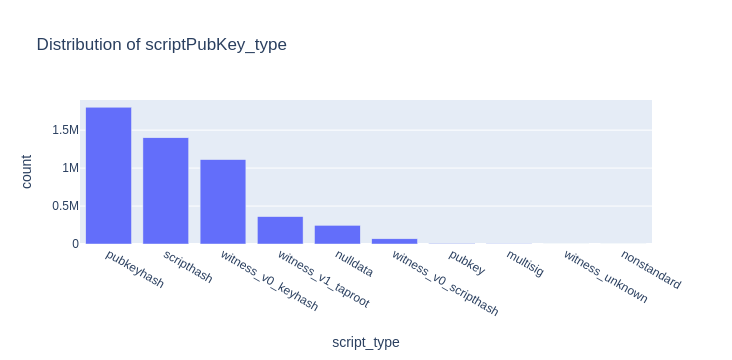

In [5]:
# === CELL 5: Distribution by scriptPubKey_type ===

script_counts = df['scriptPubKey_type'].value_counts().reset_index()
script_counts.columns = ['script_type','count']

px.bar(
    script_counts,
    x='script_type',
    y='count',
    title='Distribution of scriptPubKey_type'
)


## Temporal Enrichment: height → timestamp → age_days

In this section, each UTXO is mapped to its real block timestamp using the `blocks` table.  
This allows us to compute the age of every output (`age_days`), which is essential for:

- constructing temporal cohorts  
- analyzing supply aging  
- studying consolidation patterns  
- identifying entity‑level behavior over time  

The `age_days` metric is computed by subtracting the block timestamp from the current UTC time.


In [6]:
q_blocks = """
SELECT height, time
FROM blocks
WHERE height BETWEEN 481824 AND 945000
"""

# 1. Cargar tabla blocks
resb = client.query(q_blocks)
dfb = pd.DataFrame(resb.result_rows, columns=['height','time']).set_index('height')

# 2. Eliminar duplicados AHORA (después de crear dfb)
dfb = dfb[~dfb.index.duplicated(keep='last')]

# 3. Mapear timestamps
df['block_time'] = df['height'].map(dfb['time'])
df['block_time'] = pd.to_datetime(df['block_time'], unit='s')

# 4. Calcular edad
now = pd.Timestamp.utcnow().tz_localize(None)
df['age_days'] = (now - df['block_time']).dt.total_seconds() / 86400

df[['value_sats','age_days']].head()


/tmp/ipykernel_832585/704935322.py:19: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  now = pd.Timestamp.utcnow().tz_localize(None)


,value_sats,age_days
0,1288783803,2865.011848
1,0,2865.011848
2,11250000,2865.011848
3,38550000,2865.011848
4,364800,2865.011848


## Age Cohort Construction

We group UTXOs into temporal cohorts based on their age (`age_days`).  
These buckets allow us to analyze how supply is distributed across time and to detect:

- young supply (high turnover)  
- mid‑aged supply (moderate turnover)  
- old supply (long‑term holders)  
- historical consolidation waves from exchanges  

This step is essential for understanding the temporal structure of the modern UTXO set.

The cohorts used in this analysis are:

- <1m  
- 1–3m  
- 3–6m  
- 6–12m  
- 1–2y  
- 2–5y  
- 5–10y  
- 10y+  


In [7]:
bins = [0, 30, 90, 180, 365, 365*2, 365*5, 365*10, 99999]
labels = ['<1m','1-3m','3-6m','6-12m','1-2y','2-5y','5-10y','10y+']

df['age_bucket'] = pd.cut(df['age_days'], bins=bins, labels=labels, right=False)
df['age_bucket'].value_counts()


age_bucket
5-10y    2903356
2-5y      917250
1-2y      524288
1-3m      327553
3-6m      327553
<1m            0
6-12m          0
10y+           0
Name: count, dtype: int64

## Total Value by Age Cohort (value_sats)

We compute the total value (in satoshis) held by each age cohort.  
This reveals which temporal groups concentrate the majority of the supply.

Typical interpretation:

- Older cohorts (5–10 years) often contain large consolidations and long‑term cold storage.
- Mid‑aged cohorts (2–5 years) reflect institutional activity and recent reorganizations.
- Young cohorts (<6 months) contain small, high‑velocity outputs with frequent turnover.

This step helps us understand how value is distributed across the modern UTXO set.


In [8]:
df.groupby('age_bucket')['value_sats'].sum().sort_index()


age_bucket
1-3m      34362821368755
3-6m      27987986233977
1-2y      43416870003288
2-5y     370675854301838
5-10y    532357991361229
Name: value_sats, dtype: int64

## Distribution of log10(value_sats) by Age Cohort

This boxplot shows the distribution of UTXO values (in log10 scale) across age cohorts.

Expected patterns in a modern UTXO system:

- Heavy‑tail distribution: many small outputs and a few extremely large ones.
- Older cohorts (5–10 years) tend to exhibit longer tails due to historical consolidations.
- Younger cohorts show smaller, more compact value ranges.
- Significant outliers appear in all cohorts, typically associated with exchange movements.

This visualization allows us to compare dispersion, magnitude, and tail behavior across temporal groups.


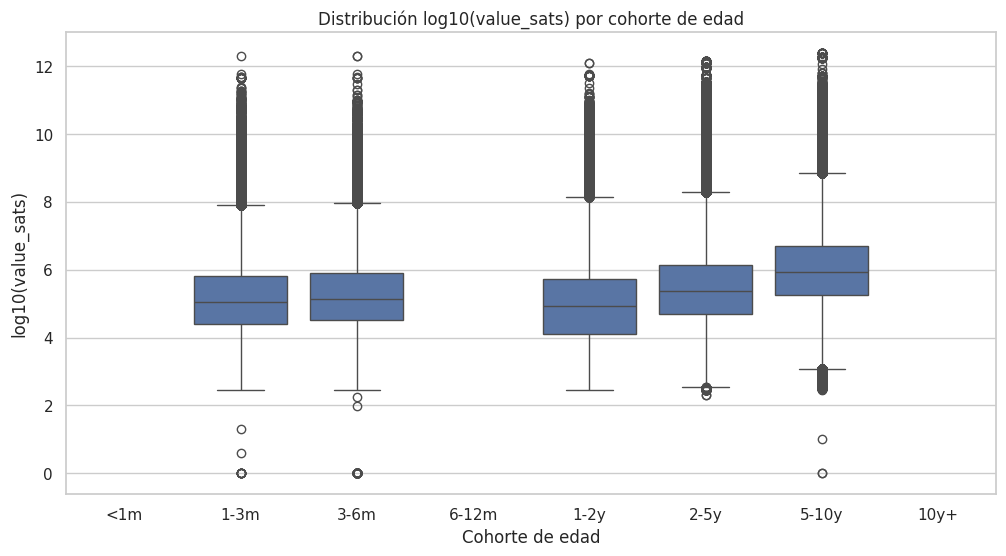

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='age_bucket', y=np.log10(df['value_sats'].replace(0, np.nan)))
plt.title('Distribución log10(value_sats) por cohorte de edad')
plt.xlabel('Cohorte de edad')
plt.ylabel('log10(value_sats)')
plt.savefig("images/boxplot_value_by_age.png", dpi=300, bbox_inches='tight')
plt.show()


## Descriptive Statistics by Age Cohort

We compute key descriptive statistics for each age cohort:

- count  
- mean  
- standard deviation  
- minimum  
- percentiles (25%, 50%, 75%)  
- maximum  

These metrics help us evaluate:

- value dispersion  
- presence and magnitude of outliers  
- structural differences between cohorts  
- behavioral patterns of entities (exchanges, custodians, users)  

The relationship **mean ≫ median** confirms the heavy‑tail nature of the UTXO value distribution.


In [10]:
df.groupby('age_bucket')['value_sats'].describe()


,count,mean,std,min,25%,50%,75%,max
age_bucket,,,,,,,,
1-3m,327553.0,1.049077e+08,5.081363e+09,0.0,13134.0,83031.0,529330.00,2.004258e+12
3-6m,327553.0,8.544567e+07,5.426058e+09,0.0,27542.0,126462.0,731623.00,1.956873e+12
1-2y,524288.0,8.281111e+07,4.351182e+09,0.0,546.0,34097.0,284052.00,1.234791e+12
2-5y,917250.0,4.041165e+08,1.595892e+10,0.0,49681.0,231403.5,1355680.25,1.456198e+12
5-10y,2903356.0,1.833595e+08,1.064904e+10,0.0,142051.0,773720.0,4478124.25,2.410520e+12


## Correlation Heatmap of UTXO Variables

In this section, we analyze the statistical relationships between the key variables in the dataset:

- `value_sats` — UTXO value in satoshis  
- `age_days` — age of the UTXO in days  
- `height` — block height  
- `script_code` — numerical encoding of `scriptPubKey_type`  

The goal is to identify structural dependencies within the modern UTXO system.

Expected patterns:

- A perfectly negative correlation between `age_days` and `height` (higher blocks are more recent).  
- Near‑zero correlation between `value_sats` and `age_days` (Bitcoin does not exhibit “value by age”).  
- Moderate correlation between `script_code` and `height` (script types evolve over time).  

This heatmap confirms that the UTXO system is **highly independent in value**, yet **strongly structured temporally**.


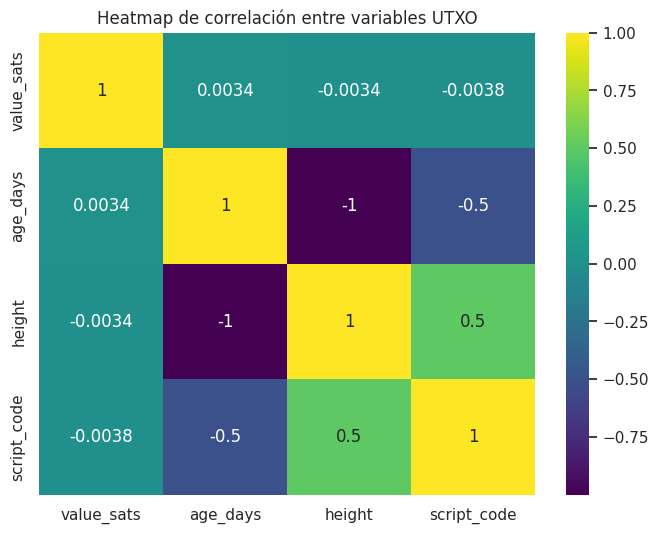

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir scriptPubKey_type a códigos numéricos
df['script_code'] = df['scriptPubKey_type'].astype('category').cat.codes

corr = df[['value_sats','age_days','height','script_code']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='viridis')
plt.title('Heatmap de correlación entre variables UTXO')
plt.savefig("images/heatmap_correlation.png", dpi=300, bbox_inches='tight')
plt.show()


## Scatter Plot: log10(value_sats) vs age_days

This scatter plot visualizes the relationship between:

- the age of the UTXO (`age_days`)  
- its value (`log10(value_sats)`)  

Typical patterns observed in real UTXO systems:

- High density of small outputs across all ages.  
- Large outliers distributed throughout the timeline, often linked to exchange consolidations.  
- Vertical clustering patterns that reflect batching behavior or consolidation events.  

The resulting structure is characteristic of a heavy‑tail system with heterogeneous activity across entities and time.


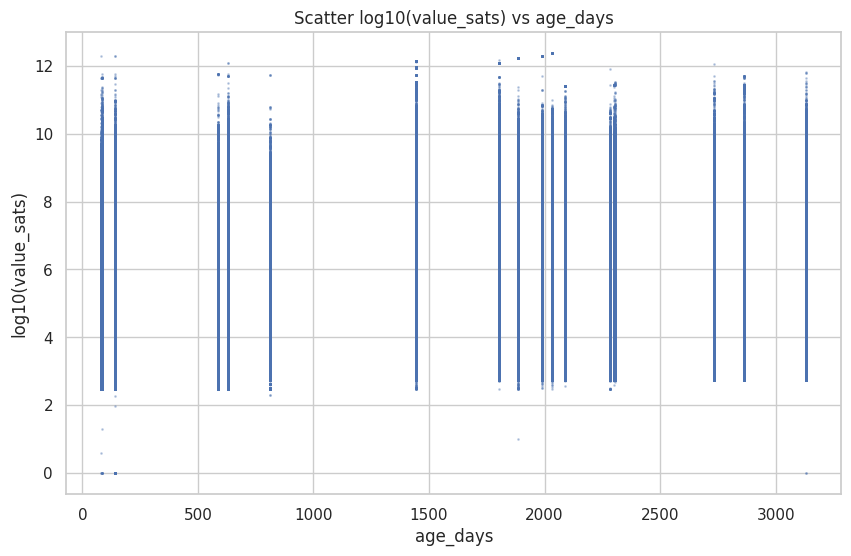

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(df['age_days'], np.log10(df['value_sats'].replace(0, np.nan)), 
            s=1, alpha=0.3)
plt.xlabel('age_days')
plt.ylabel('log10(value_sats)')
plt.title('Scatter log10(value_sats) vs age_days')
plt.savefig("images/scatter_value_vs_age.png", dpi=300, bbox_inches='tight')
plt.show()


## KDE Density of log10(value_sats) by Age Cohort

Kernel Density Estimation (KDE) allows us to compare the value distribution across age cohorts in a smooth, continuous way.

Typical observations in a real UTXO system:

- Young cohorts (<6 months) show small values and compact distributions.  
- Mid‑aged cohorts (1–5 years) exhibit wider dispersion and longer tails.  
- Older cohorts (5–10 years) contain the highest concentration of large‑value outputs.  

This analysis reveals how retained value evolves as UTXOs age, highlighting structural differences between short‑term activity and long‑term holding behavior.


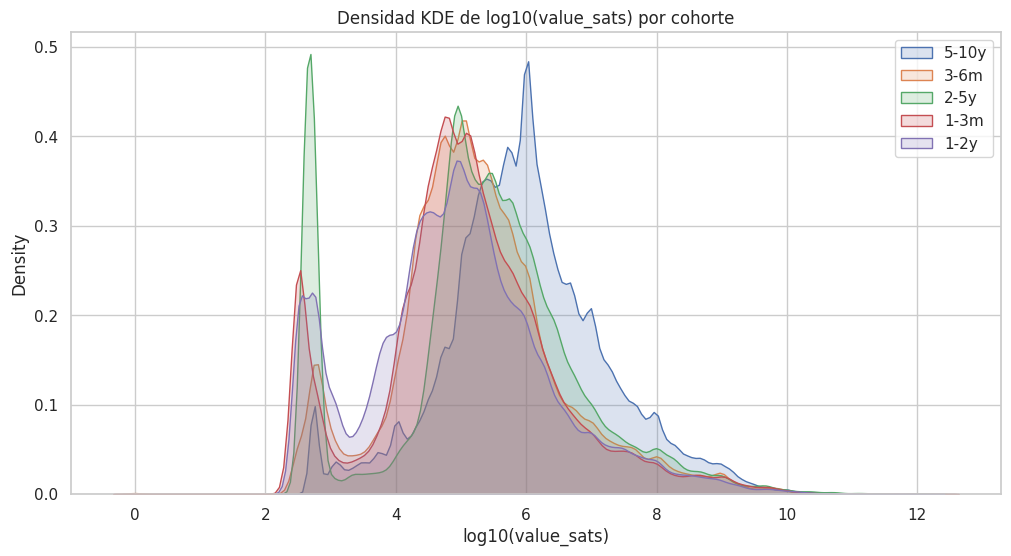

In [13]:
plt.figure(figsize=(12,6))

for bucket in df['age_bucket'].dropna().unique():
    subset = df[df['age_bucket'] == bucket]
    sns.kdeplot(np.log10(subset['value_sats'].replace(0, np.nan)), 
                label=bucket, fill=True, alpha=0.2)

plt.title('Densidad KDE de log10(value_sats) por cohorte')
plt.xlabel('log10(value_sats)')
plt.legend()
plt.savefig("images/kde_by_age_bucket.png", dpi=300, bbox_inches='tight')
plt.show()


## Outlier Analysis (Top 0.1%)

We identify the largest UTXOs in the dataset using the 99.9th percentile as the threshold.

This analysis helps us:

- detect massive consolidation events  
- identify exchange and custodian activity  
- study long‑term storage patterns  
- observe the extreme tail of the value distribution  

These outliers typically correspond to institutional movements or large wallet reorganizations.


In [14]:
threshold = df['value_sats'].quantile(0.999)
outliers = df[df['value_sats'] >= threshold]

outliers[['value_sats','age_days','scriptPubKey_type','height']].head(20)


,value_sats,age_days,scriptPubKey_type,height
17,284708187460,2865.011848,pubkeyhash,528750
23,274758087516,2865.011848,pubkeyhash,528750
26,274743488673,2865.011848,pubkeyhash,528750
29,274740837957,2865.011848,pubkeyhash,528750
33,273753000147,2865.011848,pubkeyhash,528750
126,21344205780,2865.011848,pubkeyhash,528750
176,196804415165,2865.011848,pubkeyhash,528750
379,55367022392,2865.011848,scripthash,528750
3397,133310705180,2865.011848,pubkeyhash,528750
5151,270210614418,2864.995529,pubkeyhash,528752


## Supply by Script Type and Age Cohort

We build a pivot table showing the total value (in satoshis) grouped by:

- script type (`scriptPubKey_type`)  
- age cohort (`age_bucket`)  

This analysis combines temporal structure with script‑level structure, revealing:

- Dominance of `witness_v0_keyhash` and `witness_v0_scripthash` in younger cohorts (post‑SegWit).  
- Significant presence of `pubkeyhash` and `scripthash` in older cohorts (pre‑SegWit).  
- Value concentration in the 2–5 year and 5–10 year cohorts across most script types.  
- A clear technological transition toward SegWit and Taproot over time.  

This table is essential for understanding the technological evolution of the UTXO system.


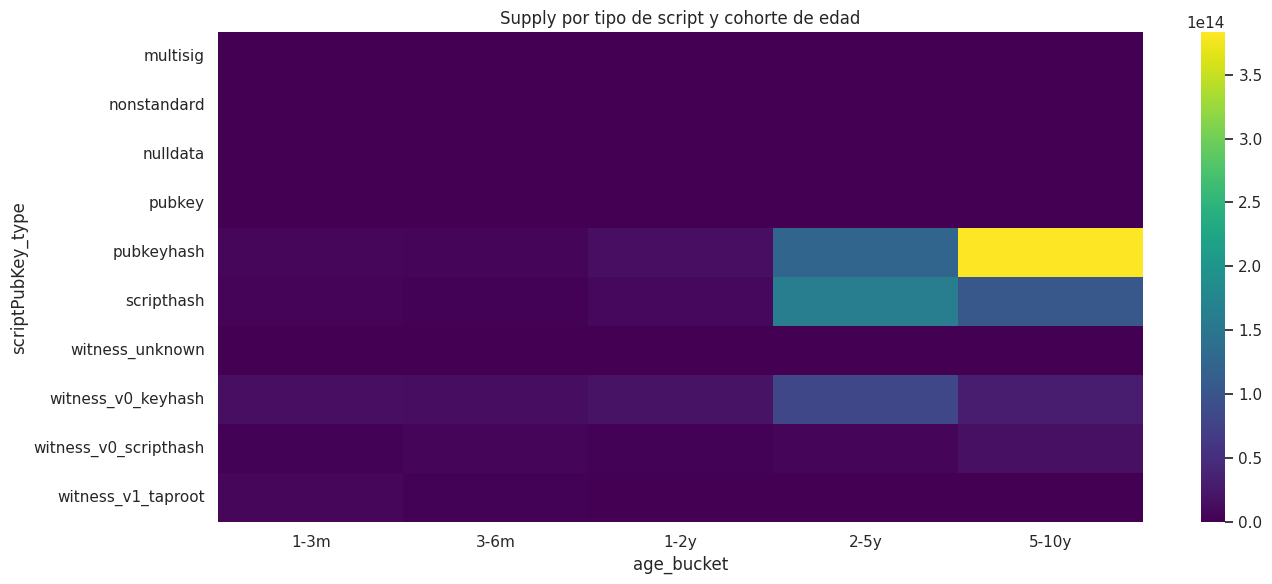

In [15]:
# ============================================
# CELDA 15 — Supply por tipo de script y cohorte
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Verificar que las columnas necesarias existen
required_cols = {"value_sats", "scriptPubKey_type", "age_bucket"}
missing = required_cols - set(df.columns)

if missing:
    raise ValueError(f"Faltan columnas necesarias en df: {missing}")

# 2. Crear tabla dinámica (pivot)
pivot = df.pivot_table(
    values="value_sats",
    index="scriptPubKey_type",
    columns="age_bucket",
    aggfunc="sum",
    fill_value=0
)

# 3. Visualización con seaborn
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=False, cmap="viridis")
plt.title("Supply por tipo de script y cohorte de edad")
plt.xlabel("age_bucket")
plt.ylabel("scriptPubKey_type")
plt.tight_layout()
# 4. Guardar imagen (ruta absoluta)
plt.savefig(
    "images/pivot_script_vs_age.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
